In [10]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = "dev_ai_articles_full.sqlite"
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql_query(
        "SELECT published_at, title, tags FROM articles WHERE published_at IS NOT NULL",
        conn,
    )

# turn date time string into datetime object
df["published_at"] = pd.to_datetime(df["published_at"])

In [11]:
df.head()


,published_at,title,tags
0,2020-08-03 03:34:11+00:00,5 Books to Fight Technopoly,"reading,technology,books,history"
1,2022-04-24 12:31:48+00:00,The Distressed Code Review,"webdev,productivity,development,codequality"
2,2020-07-19 17:45:09+00:00,Authorization and Authentication For Everyone,"authorization,security,authentication,webdev"
3,2019-11-28 11:05:44+00:00,Philosophy of a Good Developer,"productivity,webdev,beginners,career"
4,2019-11-04 18:09:42+00:00,The Future of DEV,meta


In [12]:
len(df)

2800

In [ ]:
import sqlite3
import pandas as pd

# range of dates that we have developer articles for
df["published_at"].min(), df["published_at"].max()

(Timestamp('2019-11-04 18:09:42+0000', tz='UTC'),
 Timestamp('2026-02-13 20:08:54+0000', tz='UTC'))

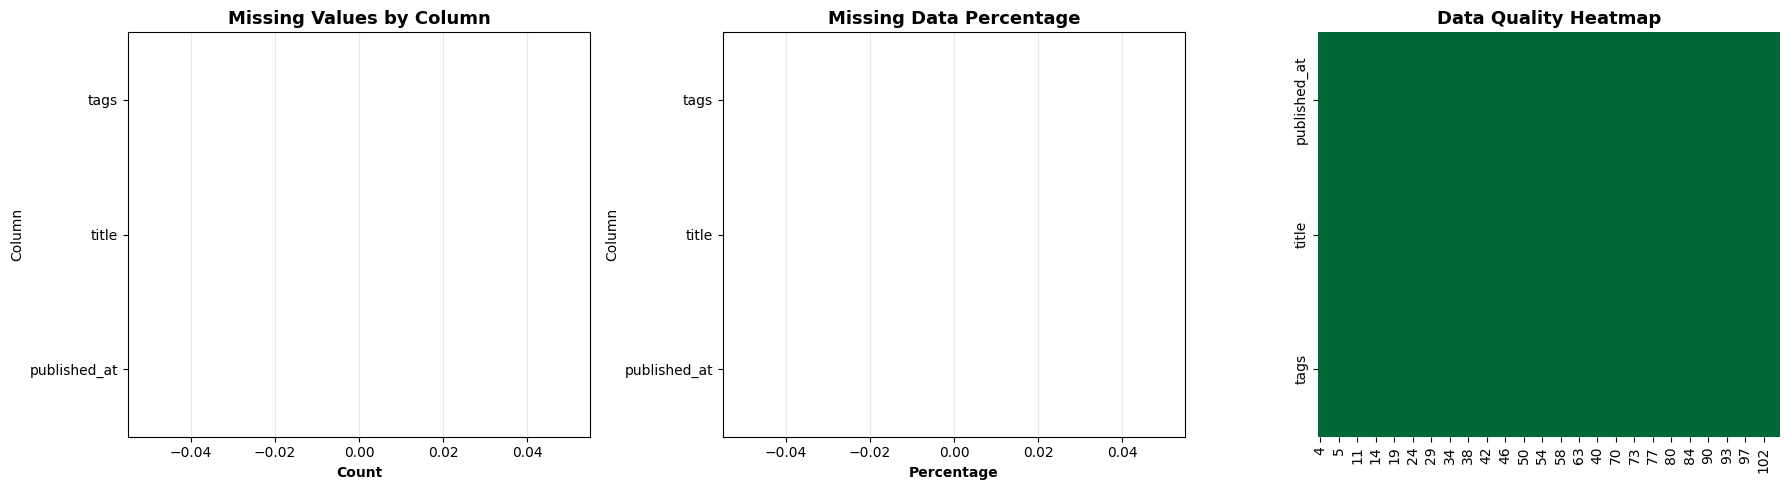

In [ ]:
import seaborn as sns

# Checking the quality of the data (missing values)
missing_data = (
    df.isnull().sum().reset_index().rename(columns={"index": "Column", 0: "Missing"})
 )
missing_data["Percent"] = (missing_data["Missing"] / len(df)) * 100

NETFLIX_RED = "#E50914"
NETFLIX_DARK = "#221F1F"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
missing_data.plot(x="Column", y="Missing", kind="barh", ax=ax, color=NETFLIX_RED, legend=False)
ax.set_xlabel("Count", fontweight="bold")
ax.set_title("Missing Values by Column", fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)

ax = axes[1]
missing_data.plot(x="Column", y="Percent", kind="barh", ax=ax, color=NETFLIX_DARK, legend=False)
ax.set_xlabel("Percentage", fontweight="bold")
ax.set_title("Missing Data Percentage", fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)

ax = axes[2]
sns.heatmap(df.isnull().T.iloc[:, :100], cmap="RdYlGn_r", cbar=False, ax=ax)
ax.set_title("Data Quality Heatmap", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("images/missing_values.png", dpi=300, bbox_inches="tight")
plt.show()

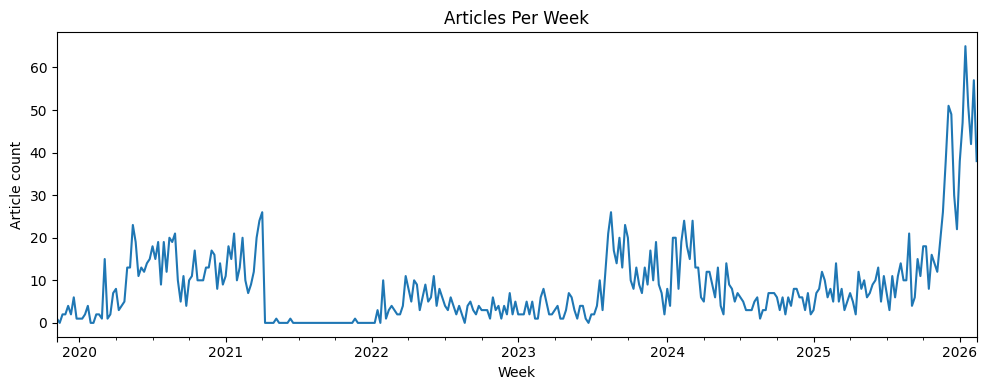

In [16]:
# Weekly posting of articles
per_week = df.set_index("published_at").resample("W").size()
plt.figure(figsize=(10, 4))
per_week.plot()
plt.title("Articles Per Week")
plt.xlabel("Week")
plt.ylabel("Article count")
plt.tight_layout()
plt.show()

NameError: name 'NETFLIX_RED' is not defined

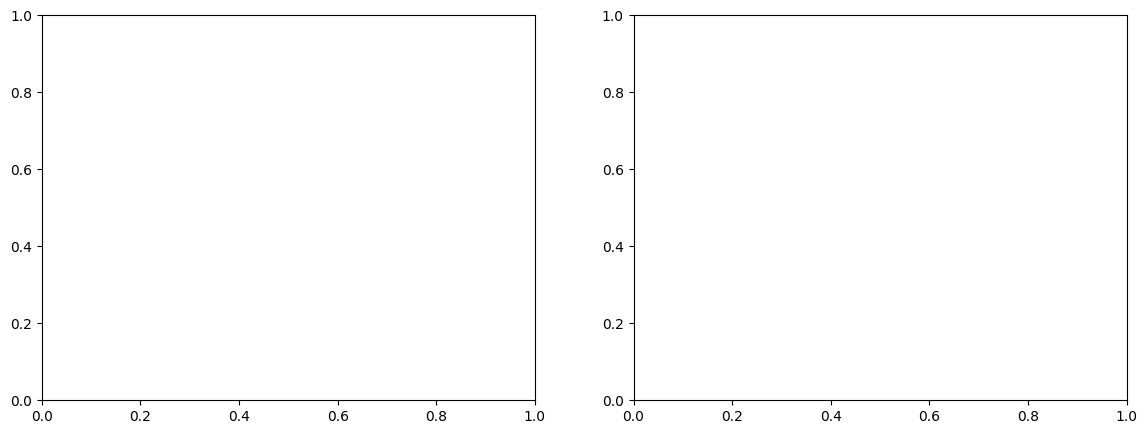

In [17]:
# Yearly and seasonal release comparison
df["year_released"] = df["published_at"].dt.year
df["month_released"] = df["published_at"].dt.month

year_counts = df["year_released"].value_counts().sort_index()
month_counts = df["month_released"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(year_counts.index, year_counts.values, marker="o", color=NETFLIX_RED, linewidth=2.5, markersize=6)
ax.set_xlabel("Year Released", fontweight="bold")
ax.set_ylabel("Count", fontweight="bold")
ax.set_title("Release Year Trend", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(month_counts.index, month_counts.values, color=NETFLIX_DARK, edgecolor="black")
ax.set_xlabel("Month", fontweight="bold")
ax.set_ylabel("Count", fontweight="bold")
ax.set_title("Seasonal Release Pattern", fontsize=13, fontweight="bold")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], rotation=45)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("images/release_seasonality.png", dpi=300, bbox_inches="tight")
plt.show()

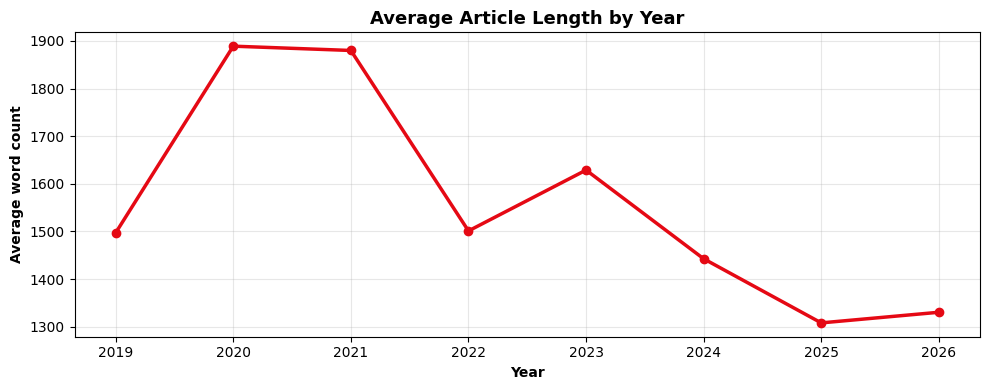

In [ ]:
# Average article word count by year
with sqlite3.connect(DB_PATH) as conn:
    text_df = pd.read_sql_query(
        """
        SELECT published_at, body_text
        FROM articles
        WHERE published_at IS NOT NULL AND body_text IS NOT NULL
        """,
        conn,
    )

text_df["published_at"] = pd.to_datetime(text_df["published_at"], utc=True, errors="coerce")
text_df = text_df.dropna(subset=["published_at"])
text_df["year_released"] = text_df["published_at"].dt.year
text_df["word_count"] = text_df["body_text"].str.split().str.len()

yearly_avg = text_df.groupby("year_released")["word_count"].mean().sort_index()

plt.figure(figsize=(10, 4))
plt.plot(yearly_avg.index, yearly_avg.values, marker="o", color=NETFLIX_RED, linewidth=2.5, markersize=6)
plt.title("Average Article Length by Year", fontsize=13, fontweight="bold")
plt.xlabel("Year", fontweight="bold")
plt.ylabel("Average word count", fontweight="bold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images/avg_length_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

count     2800.000000
mean      1548.009643
std       1222.125957
min         34.000000
10%        552.000000
25%        820.000000
50%       1245.000000
75%       1884.000000
90%       2825.400000
max      23735.000000
Name: word_count, dtype: float64
IQR: 1064.0 words


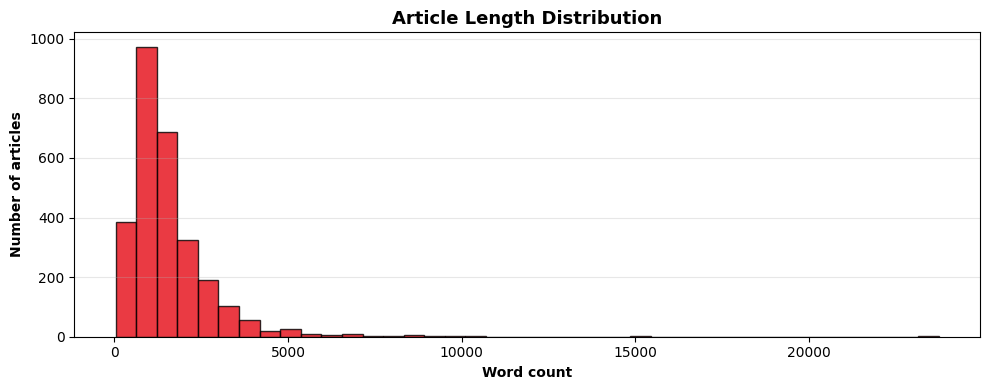

In [24]:
# Text length summary stats (word count)
with sqlite3.connect(DB_PATH) as conn:
    length_df = pd.read_sql_query(
        """
        SELECT body_text
        FROM articles
        WHERE body_text IS NOT NULL
        """,
        conn,
    )

length_df["word_count"] = length_df["body_text"].str.split().str.len()

stats = length_df["word_count"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
print(stats)

iqr = stats["75%"] - stats["25%"]
print(f"IQR: {iqr:.1f} words")

plt.figure(figsize=(10, 4))
plt.hist(length_df["word_count"], bins=40, color=NETFLIX_RED, edgecolor="black", alpha=0.8)
plt.title("Article Length Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Word count", fontweight="bold")
plt.ylabel("Number of articles", fontweight="bold")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("images/word_count_hist.png", dpi=300, bbox_inches="tight")
plt.show()

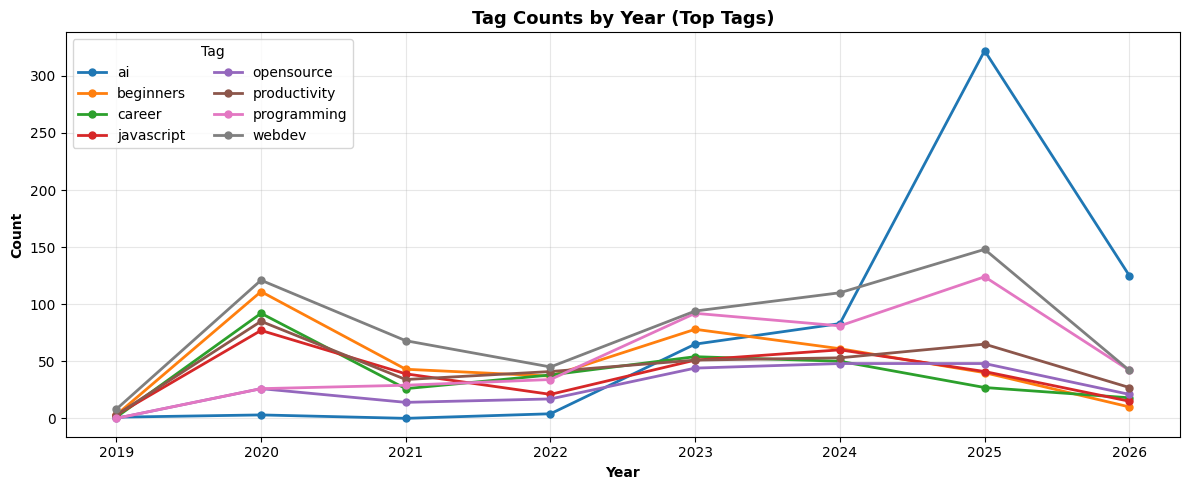

In [18]:
# Tag counts by year (top tags)
with sqlite3.connect(DB_PATH) as conn:
    tag_df = pd.read_sql_query(
        """
        SELECT published_at, tags
        FROM articles
        WHERE published_at IS NOT NULL AND tags IS NOT NULL
        """,
        conn,
    )

tag_df["published_at"] = pd.to_datetime(tag_df["published_at"], utc=True, errors="coerce")
tag_df = tag_df.dropna(subset=["published_at"])
tag_df["year_released"] = tag_df["published_at"].dt.year

tag_df["tags"] = tag_df["tags"].str.split(",")
tag_df = tag_df.explode("tags")
tag_df["tags"] = tag_df["tags"].str.strip()
tag_df = tag_df[tag_df["tags"].ne("")]

# Pick top tags overall for a clean plot
top_tags = tag_df["tags"].value_counts().head(8).index
tag_df = tag_df[tag_df["tags"].isin(top_tags)]

tag_year_counts = (
    tag_df.groupby(["year_released", "tags"]).size().unstack(fill_value=0).sort_index()
)

plt.figure(figsize=(12, 5))
for tag in tag_year_counts.columns:
    plt.plot(
        tag_year_counts.index,
        tag_year_counts[tag],
        marker="o",
        linewidth=2.0,
        markersize=5,
        label=tag,
    )

plt.title("Tag Counts by Year (Top Tags)", fontsize=13, fontweight="bold")
plt.xlabel("Year", fontweight="bold")
plt.ylabel("Count", fontweight="bold")
plt.grid(True, alpha=0.3)
plt.legend(title="Tag", ncol=2)
plt.tight_layout()
plt.savefig("images/tag_counts_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

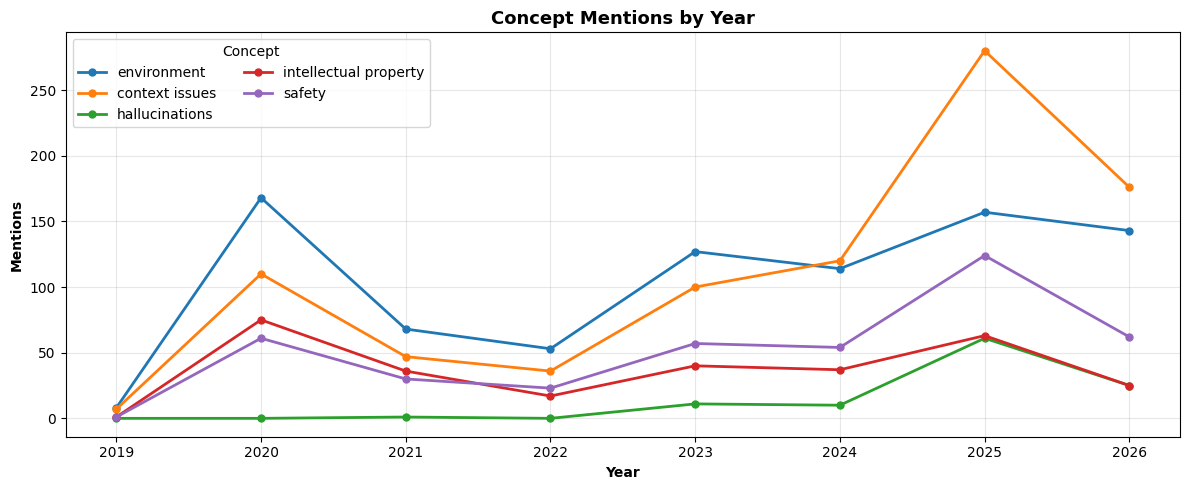

In [19]:
# Concept mentions by year (body_text)
import re

concept_patterns = {
    "environment": r"\benvironment\b",
    "context issues": r"\bcontext\b|\bcontext issues\b|\bcontext window\b",
    "hallucinations": r"\bhallucination\b|\bhallucinations\b",
    "intellectual property": r"\bip\b|\bintellectual property\b|\bcopyright\b|\blicens\w*\b",
    "safety": r"\bsafety\b|\balignment\b|\bmisuse\b",
}

with sqlite3.connect(DB_PATH) as conn:
    concept_df = pd.read_sql_query(
        """
        SELECT published_at, body_text
        FROM articles
        WHERE published_at IS NOT NULL AND body_text IS NOT NULL
        """,
        conn,
    )

concept_df["published_at"] = pd.to_datetime(concept_df["published_at"], utc=True, errors="coerce")
concept_df = concept_df.dropna(subset=["published_at"])
concept_df["year_released"] = concept_df["published_at"].dt.year
concept_df["body_text"] = concept_df["body_text"].str.lower()

for concept, pattern in concept_patterns.items():
    concept_df[concept] = concept_df["body_text"].str.contains(pattern, regex=True, na=False)

yearly_mentions = concept_df.groupby("year_released")[list(concept_patterns.keys())].sum().sort_index()

plt.figure(figsize=(12, 5))
for concept in yearly_mentions.columns:
    plt.plot(
        yearly_mentions.index,
        yearly_mentions[concept],
        marker="o",
        linewidth=2.0,
        markersize=5,
        label=concept,
    )

plt.title("Concept Mentions by Year", fontsize=13, fontweight="bold")
plt.xlabel("Year", fontweight="bold")
plt.ylabel("Mentions", fontweight="bold")
plt.grid(True, alpha=0.3)
plt.legend(title="Concept", ncol=2)
plt.tight_layout()
plt.savefig("images/concept_mentions_by_year.png", dpi=300, bbox_inches="tight")
plt.show()